In [1]:
# using pandas==0.25.1, seaborn==0.9.0, pyarrow==0.15.1
import pandas as pd
import json
import os
import numpy as np; np.random.seed(42)
from glob import glob
from tqdm import tqdm
import seaborn as sns
import pdb
from collections import Counter
from itertools import cycle
from sklearn.metrics import auc
from matplotlib.patches import Rectangle 

import sys; sys.path.append('..')

# !pip install textalloc
import textalloc as ta

import matplotlib.pyplot as plt
import matplotlib


matplotlib.rc("pdf", fonttype=42)
matplotlib.rc("ps", fonttype=42)

sns.set(style="ticks", palette="magma")  # style='whitegrid', palette='magma'
sns.set_context("paper", font_scale=1.25, rc={"lines.linewidth": 1.1})

# gridsearch for each dataset-run before fitting the final model
rdir  = '../../results/black-box-tuning/'
figdir = f'../figs/black-box-tuning/'
datadir = '../../datasets/blackbox/' # Set to path to datasets

def save(name='tmp', h=None, figdir=None):
    name = name.strip().replace(' ','-').replace('%','pct')
    if h == None:
        h = plt.gcf()

    h.tight_layout()

    if figdir is not None:
        print('saving',figdir+'/'+name+'.pdf')

        if not os.path.exists(figdir):
            os.makedirs(figdir)

        plt.savefig(figdir+'/'+name+'.pdf', bbox_inches='tight')
        plt.savefig(figdir+'/'+name+'.png', bbox_inches='tight')
    else: # just show it
        print('plot was not saved because no figdir was specified')
        plt.show()

In [2]:
df_sum = pd.read_csv(rdir+'results-summary.csv.gz', compression='gzip')
df = pd.read_feather(rdir+'results.feather') # raw --- reporting results for each run and each dataset

display(df_sum.sample())
display(df.sample())
print(df.random_state.unique())

print('mean trial count:')
print(df.groupby('algorithm')['dataset'].count().sort_values()
      / df.dataset.nunique())

df = df[~df['algorithm'].isin(['Genetic Engine rs', 'Genetic Engine hc', 'Genetic Engine 1p1'])]

df_plot=df.copy().fillna(-1)
df_plot.loc[df_plot.r2_test < 0,'r2_test'] = -1 # clipping r2_test
df_plot["log_model_size"] = np.log(df_plot.model_size)

# including-excluding specific results -----------------------------------------

# df_plot = df_plot[~df_plot['algorithm'].isin(['AFP_FE'])]

# df_plot = df_plot[~df_plot['algorithm'].isin([
#     'E2E', 'TPSR', 'NeSymRes'
# ])]

# filter by random state to have only 10 first runs
# df_plot = df_plot[~df_plot['random_state'].isin([
#     '14423', '15795', '16850', '21962', '23654', '28020', '29910', '4426', '5390', '860'
# ])]


,algorithm,dataset,random_state,training time (s),mse_test,mae_test,r2_test,model_size,training time (hr),symbolic_alg,...,r2_test_rank,r2_test_norm,model_size_rank,model_size_norm,r2_zero_test_rank,r2_zero_test_norm,rmse_test_rank,rmse_test_norm,log_mse_test_rank,log_mse_test_norm
30,BSR,1193_BNG_lowbwt,16436.5,1344.671239,239262.643909,398.576978,0.544989,13.0,0.37352,True,...,9.0,0.657735,4.0,0.007181,9.0,0.657735,9.0,0.347897,9.0,0.367645


,dataset,algorithm,random_state,training time (s),symbolic_model,mse_test,mae_test,r2_test,model_size,params_str,...,pre_trained,gp_alg,r2_zero_test,friedman_dataset,algorithm_count,mse_test_rank_per_trial,mae_test_rank_per_trial,r2_test_rank_per_trial,model_size_rank_per_trial,r2_zero_test_rank_per_trial
6384,678_visualizing_environmental,Bingo,29802,3326.354737,(-0.5604429476150328)*(ozone + (-0.16421933856...,9.636253,2.654237,0.041328,51,"{'clo_alg': 'lm', 'clo_threshold': 1e-05, 'cro...",...,False,False,0.041328,False,24,14.0,18.0,14.0,18.0,14.0


[11284 11363 11964 14423 15795 16023 16850  1685 21575 21962 22118 23333
 23654  2433 26967 27495 28020 29802 29910 30187 32052 32157  4426  5051
  5311  5390  6265   769  8322   860]
mean trial count:
algorithm
NeSymRes           5.666667
TPSR               5.666667
PS-Tree           10.166667
AFP_FE            14.250000
Brush             19.666667
FEAT              20.083333
E2E               20.583333
AFP_EHC           25.000000
EPLEX             25.000000
TIR               25.083333
AFP               25.166667
ITEA              27.500000
PYSR              27.500000
Operon            27.750000
BSR               29.500000
Rils-Rols         29.750000
GPZGD             30.000000
Genetic Engine    30.000000
FFX               30.000000
GP-GOMEA          30.000000
EQL               30.000000
Bingo             30.000000
QLattice          30.000000
gplearn           30.000000
Name: dataset, dtype: float64


/home/ch246537/.conda/envs/srbench-brush-cpp/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [3]:
intervals = (
    ('years', 31534272),  # 60 * 60 * 24 * 7 * 52.14
    ('weeks', 604800),    # 60 * 60 * 24 * 7
    ('days', 86400),      # 60 * 60 * 24
    ('hours', 3600),      # 60 * 60
    ('minutes', 60),      
    ('seconds', 1),
)

def display_time(seconds, granularity=7):
    result = []

    for name, count in intervals:
        value = seconds // count
        if value:
            seconds -= value * count
            if value == 1:
                name = name.rstrip('s')
            result.append("{} {}".format(int(value), name))
    return ', '.join(result[:granularity])

# Just for calculating execution time
print('Total training time', display_time(df['training time (s)'].sum()))

Total training time 10 weeks, 3 days, 6 hours, 5 minutes, 50 seconds


saving ../figs/black-box-tuning//r2_perf_full.pdf


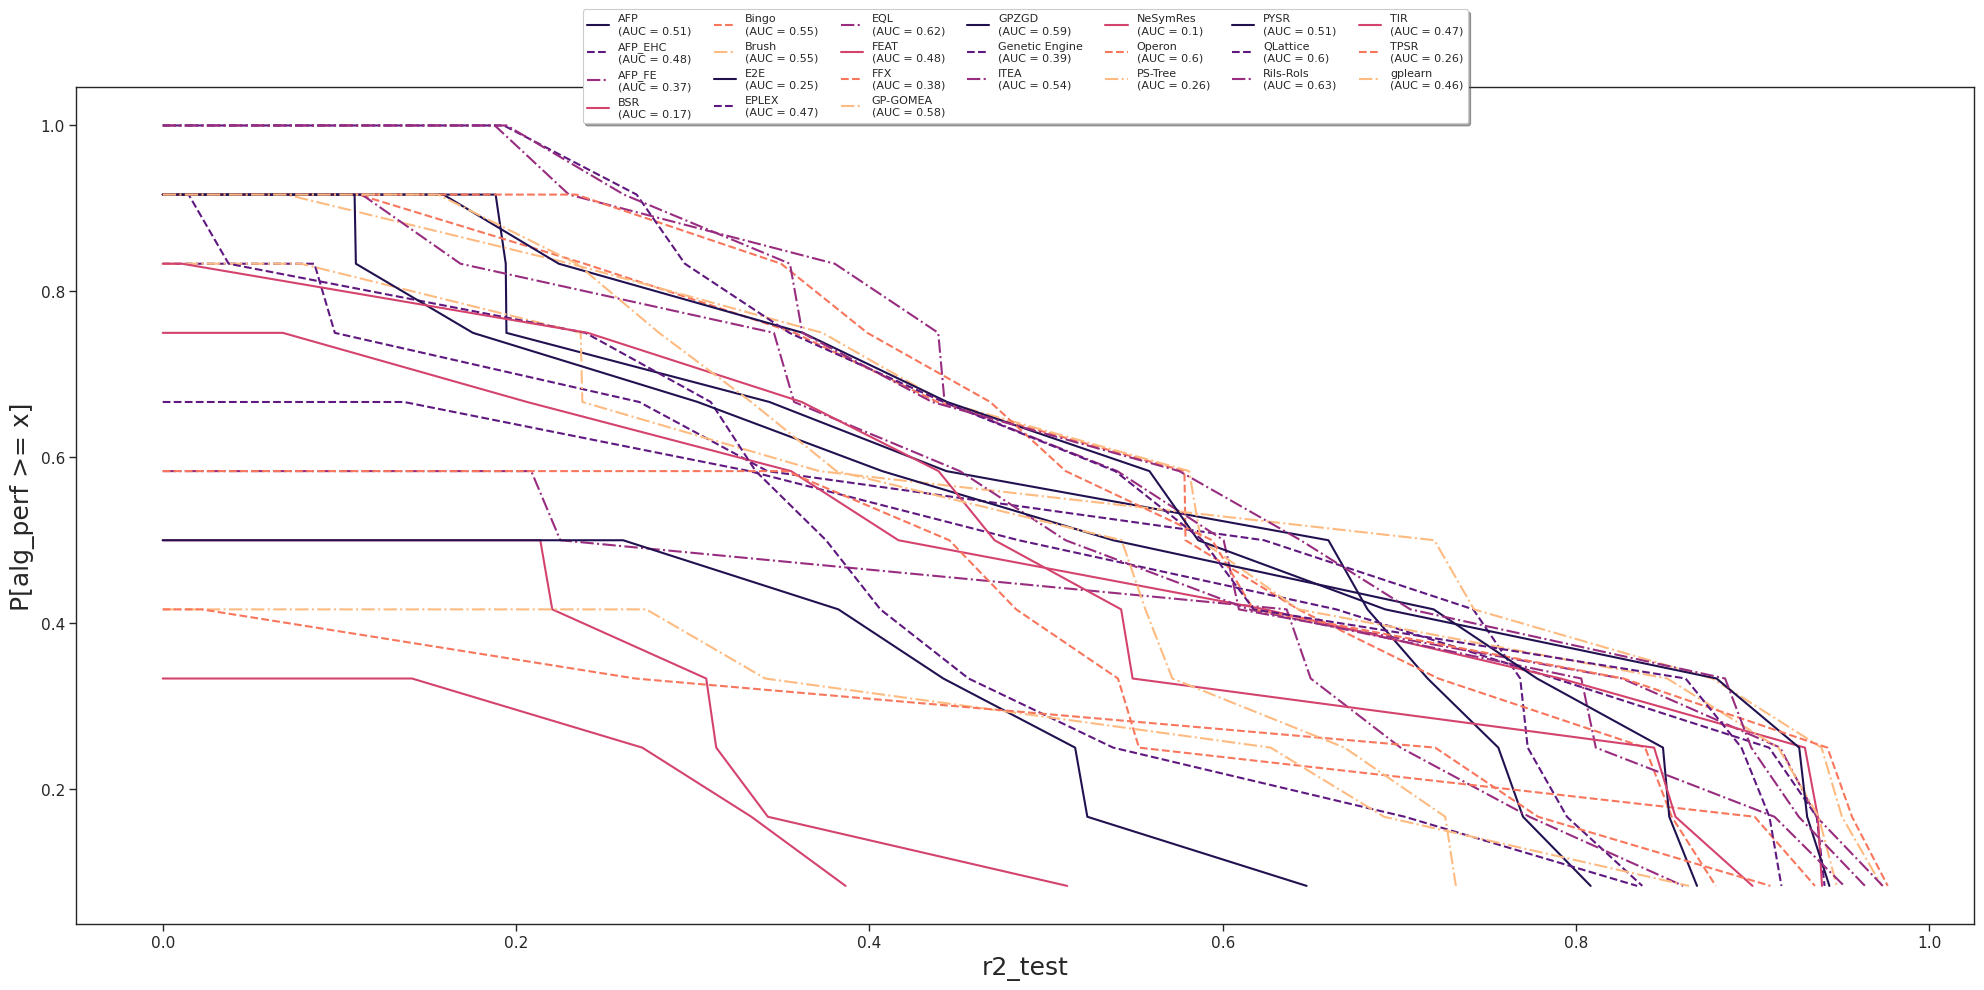

In [4]:
# works with df_sum
def perfprof_plot_sum(df, perf_measure, interval=(0.0, 1.0), ax=None, legend=True):
    lines = ["-","--","-."]
    linecycler = cycle(lines)
    
    suffix = "" if interval == (0.0, 1.0) else f" with AUC in {interval}".replace(", ", "-")
    
    if ax is None:
        plt.figure(figsize=(20,10))
        ax = plt.gca()

    tab = df.pivot(index="algorithm", columns="dataset", values=perf_measure)
    n_problems = len(tab.columns)
    for name, v in tab.iterrows():
        v = v[v>=0].sort_values()
        # print(v)
        n_gt0 = v.shape[0]
        perf_x = [0]
        perf_y = [n_gt0/n_problems]
        for k, v1 in Counter(v).items():
            if k == 0:
                n_gt0 = n_gt0 - v1
                continue
            perf_x.append(k)
            perf_y.append(n_gt0/n_problems)
            n_gt0 = n_gt0 - v1

        AUC = auc(perf_x, perf_y)
        if interval[0] <= AUC <= interval[1]:
            ax.plot(perf_x, perf_y, next(linecycler), linewidth=1.5, label=f'{name}\n(AUC = {np.round(AUC,2)})')
        else:
            ax.plot(perf_x, perf_y, ":", c='gray', alpha=0.25)
    
    ax.set_xlabel(perf_measure, fontsize=18)
    ax.set_ylabel("P[alg_perf >= x]"+suffix, fontsize=18)
    if legend:
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1),
                ncol=7, fancybox=True, shadow=True, prop={'size': 8})

df_plot_sum = df_plot.groupby(["algorithm","dataset"])[['r2_test', 'model_size']].mean().reset_index()
perfprof_plot_sum(df_plot_sum, 'r2_test')
save(name='r2_perf_full', figdir=figdir)

In [5]:
# works with df
def perfprof_plot(df, perf_measure, interval=(0.0, 1.0), errorbar=None, estimator=np.median,
    annot=True, ax=None, legend=True, xlabel=True, ylabel=True):
    dashes = [ (1,2), (4,1), (3,2,1,2), (3,1,1,1), (1,1), (2,4), (5,5), (1,3)]
    dashcycler = cycle(dashes)

    markers = ['o', 's', 'D', '^', 'v', '<', '>', 'P', '*', 'X', 'h']
    markercycler = cycle(markers)
    
    # Used in ROC curve plots, number of steps
    base_fpr = np.linspace(0, 1, 51)
    
    suffix = "" if interval == (0.0, 1.0) else \
             f" - AUC $\in {interval}$".replace(", ", "-").replace("(", "[")
    
    if ax is None:
        plt.figure(figsize=(15,7))
        ax = plt.gca()

    df = df[['algorithm', 'dataset', 'random_state', perf_measure]]

    n_problems = df['dataset'].unique().size

    plot_data = []
    for name, view in df.groupby('algorithm'):
        view = view[view[perf_measure]>=0].sort_values(by=perf_measure)

        # finding out the performance across different datasets (because we fix random_seed)
        frames, AUCs = [], []
        for rs, view2 in view.groupby('random_state'):
            n_gt0 = view2.shape[0]
            perf_x = [0]
            perf_y = [n_gt0/n_problems]
            
            for k, perf in Counter(view2[perf_measure].values).items():
                if k == 0: # initial value is set outside this for loop
                    n_gt0 = n_gt0 - perf
                    continue
                perf_x.append(k)
                perf_y.append(n_gt0/n_problems)
                n_gt0 = n_gt0 - perf
            
            perf_y = np.interp(base_fpr, perf_x, perf_y)
            AUCs.append( auc(base_fpr, perf_y))
            frames = frames + [{
                'perf_x': x,
                'perf_y': y,
                'random_state' : rs,
                'algorithm' : name, # used for linestyle
                'AUC' : auc(base_fpr, perf_y)
            } for (x, y) in zip(base_fpr, perf_y)]

        # Storing the values --- we will plot them ordered by AUC later
        df_frames = pd.DataFrame.from_records(frames)
        AUC = estimator(AUCs)
        plot_data.append((AUC, name, df_frames))

    plot_data.sort(key=lambda x: x[0]) # sorting in-place by AUC

    # keeping track of which color and marker we use for each line
    cmap = np.array(sns.color_palette("Spectral", n_colors=len(plot_data)) )
    marker_dict, dashes_dict = {}, {}

    algs_in = pd.DataFrame()

    # Keeping track of when to start and stop to iterate over the colormap, 
    # so the colors matches across different intervals
    c_idxs = []
    for i, (AUC, name, df_frames) in enumerate(plot_data):
        pretty_name = f'{name}\n(AUC={np.round(AUC,2)})'
        df_frames['algorithm'] = pretty_name
        if interval[0] <= AUC <= interval[1]:
            marker_dict[pretty_name] = next(markercycler)
            dashes_dict[pretty_name] = next(dashcycler)
            algs_in = pd.concat([algs_in, df_frames])
            c_idxs.append(i)
        else:
            sns.lineplot(data=df_frames, x='perf_x', y='perf_y', linewidth=1, ls=":", ax=ax,
                        alpha=0.2, color='gray', ci=None, label=None, estimator=estimator)

    # print("Color idxs:", c_idxs)
    # print({a:next(dashcycler) for a in algs_in['algorithm'].unique()})
    if algs_in.shape[0]>0:
        ax = sns.lineplot(data=algs_in, x='perf_x', y='perf_y', linewidth=1, ax=ax,
                        color=cmap[c_idxs], ci=errorbar, estimator=estimator,
                        hue='algorithm', style='algorithm', alpha=0.75,
                        markeredgewidth=0, markers=marker_dict,
                        dashes=dashes_dict)

        if annot:
            # Annotations - first we find the curves using the agg function, then 
            # we plot the names following their order in AUC
            grouped_lines = algs_in.groupby(['algorithm', 'perf_x']).agg(estimator)\
                        .reset_index().sort_values('AUC')
            # display(grouped_lines)

            closest_fpr_point = lambda p: min(base_fpr, key=lambda x:abs(x-p))
            x = [closest_fpr_point(xpos) for xpos in np.linspace(0.05, 0.95, len(grouped_lines['algorithm'].unique()))]
            y = [grouped_lines[grouped_lines['perf_x']==xpos]['perf_y'].max() for xpos in x]
            y_line = [grouped_lines[ (grouped_lines['perf_x']==closest_fpr_point(xpos))
                                & (grouped_lines['algorithm']==alg)]['perf_y'].max()
                    for xpos, alg in zip(x, grouped_lines['algorithm'].unique())]
            
            ta.allocate(ax, x, y_line, grouped_lines['algorithm'].unique(), min_distance=0.02, avoid_label_lines_overlap=True, avoid_crossing_label_lines=True,
                        x_scatter=x, y_scatter=y, textsize=8, **{"bbox":dict(facecolor='w', edgecolor='b', boxstyle='round', alpha=0.75)})

    ax.set_xlim((0, 1.0))
    
    label = perf_measure.replace('_', ' ').replace(' test', '').replace('r2', 'R^2').title()
    if xlabel:
        ax.set_xlabel(f"${label}$ ({estimator.__name__})") #, fontsize=18)
    else:
        ax.set_xlabel("")

    if ylabel:
        ax.set_ylabel(f"P[${label} \geq x$]"+suffix) #, fontsize=18)
    else:
        ax.set_ylabel("")

    if legend:
        leg = ax.legend(loc='lower left', # bbox_to_anchor=(0.75, 1.0),
                ncol=3, fancybox=False, shadow=False, prop={'size': 8})
        for legobj in leg.legendHandles:
            legobj.set_linewidth(1.0)
    else:
        ax.get_legend().remove()
        
    ax.grid(axis='x')
    sns.despine()

/home/ch246537/.conda/envs/srbench-brush-cpp/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ch246537/.conda/envs/srbench-brush-cpp/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


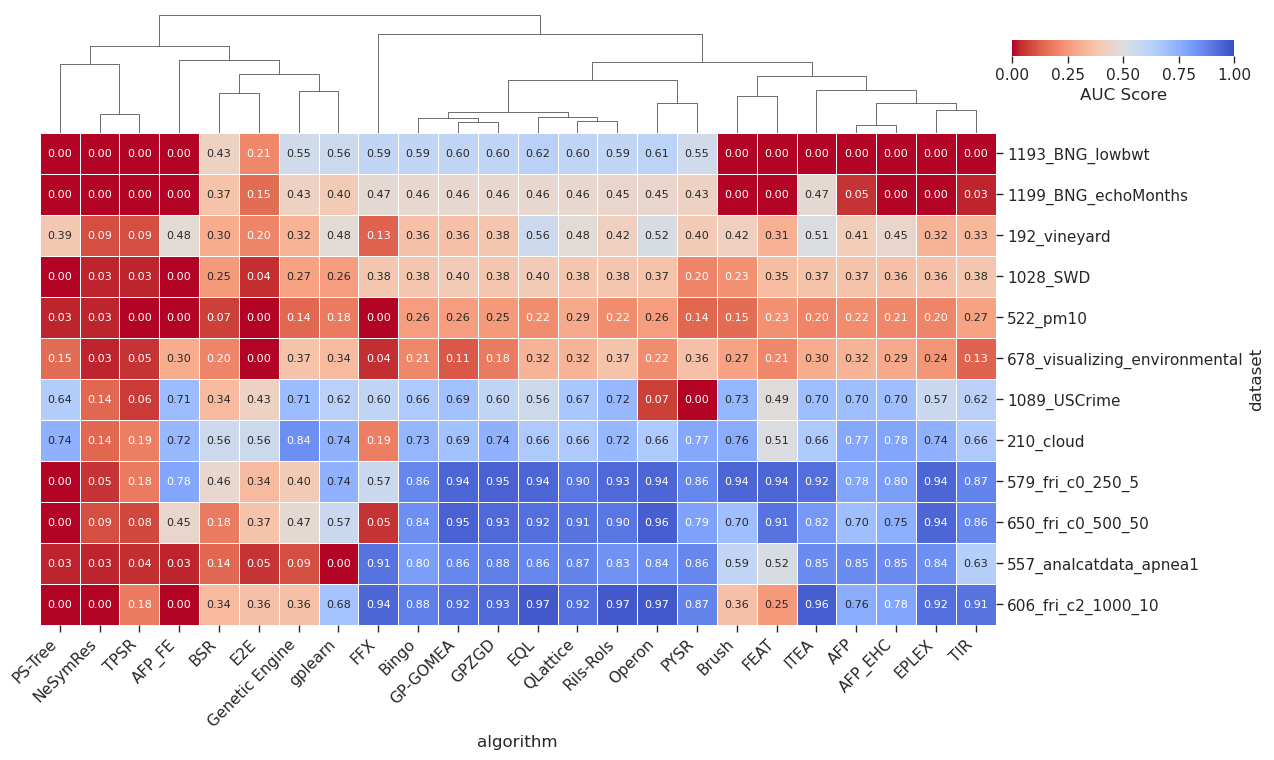

In [6]:
def perf_table(df, perf_measure, interval=(0.0, 1.0), errorbar=None):
    # Used in ROC curve plots, number of steps
    base_fpr = np.linspace(0, 1, 51)

    df = df[['algorithm', 'dataset', 'random_state', perf_measure, 'model_size']]
    n_problems = df['random_state'].unique().size

    data = []
    for (alg, ds), view in df.groupby(['algorithm', 'dataset']):
        view = view[view[perf_measure]>=0].sort_values(by=perf_measure)

        n_gt0 = view.shape[0]
        perf_x = [0]
        perf_y = [n_gt0/n_problems]
        for k, perf in Counter(view[perf_measure].values).items():
            if k == 0: # initial value is set outside this for loop
                n_gt0 = n_gt0 - perf
                continue
            perf_x.append(k)
            perf_y.append(n_gt0/n_problems)
            n_gt0 = n_gt0 - perf
        
        perf_y = np.interp(base_fpr, perf_x, perf_y)
        AUC = auc(base_fpr, perf_y)
        mean_size = np.mean(view['model_size'].values)
        counts = len(view[view['model_size']>0])
        data.append( (alg, ds, AUC, mean_size, counts) )

    perf_table_df = pd.DataFrame(data=data, columns=['algorithm', 'dataset', 'AUC', 'mean_model_size', 'valid'])

    return perf_table_df
    
perf_table_df = perf_table(df_plot, "r2_test", errorbar=None)
perf_table_pivot = perf_table_df.pivot(columns='algorithm', index='dataset', values='AUC').round(2).fillna(0.000)

# perf_table_pivot.style.background_gradient(axis=None, cmap='coolwarm_r')

g = sns.clustermap(
    perf_table_pivot,
    annot=True,
    fmt='.2f',
    cmap='coolwarm_r',
    center=0.5,
    vmin=0,
    vmax=1,
    annot_kws={'size': 8},
    linewidths=0.5,
    square=False,
    cbar_pos=(.82, .92, .148, .019),
    cbar_kws={'label': 'AUC Score', "orientation": "horizontal"},
    figsize=(15, 8)
)

# g.ax_heatmap.set_ylabel("")
# g.ax_heatmap.set_xlabel("")
g.ax_row_dendrogram.set_visible(False) #suppress row dendrogram
# g.ax_col_dendrogram.set_visible(False) #suppress column dendrogram

plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
# plt.tight_layout()
plt.show()

/tmp/ipykernel_590406/324054466.py:84: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(data=algs_in, x='perf_x', y='perf_y', linewidth=1, ax=ax,


saving ../figs/black-box-tuning//r2_perf_full.pdf


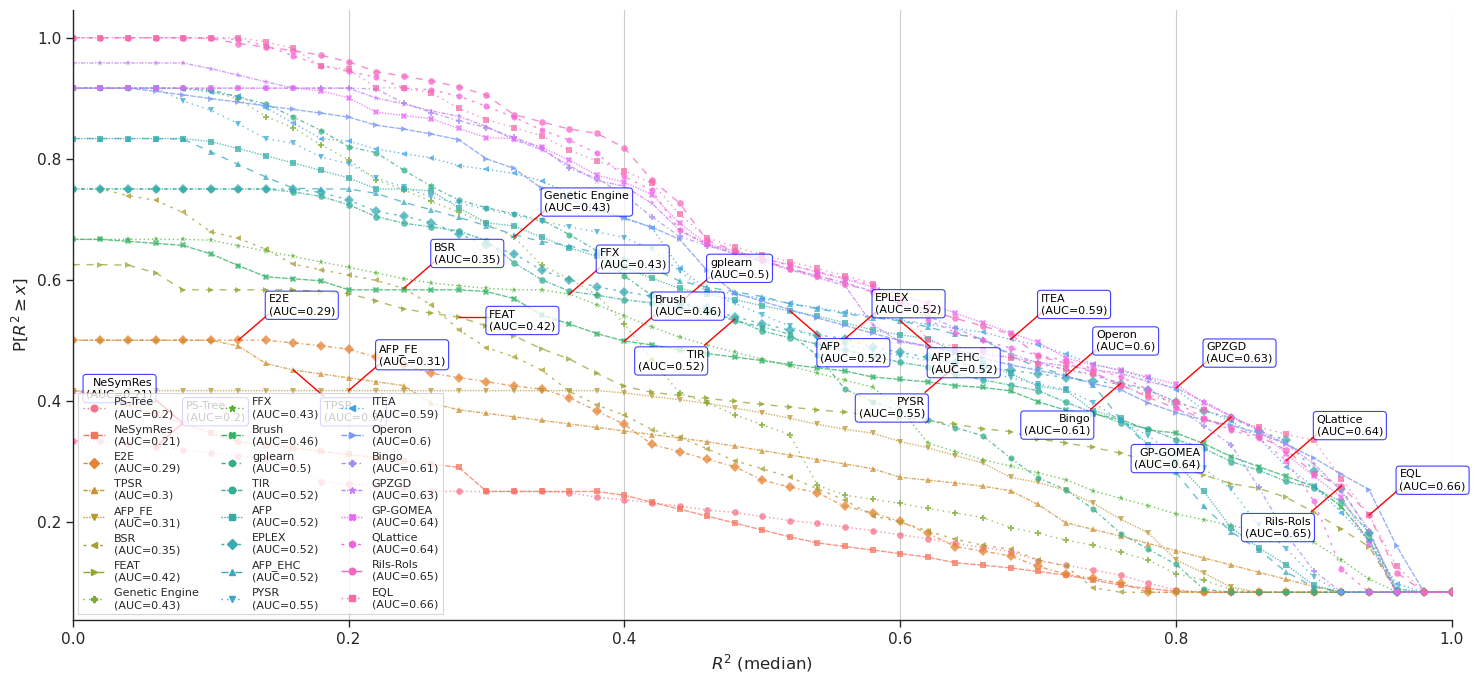

In [7]:
perfprof_plot(df_plot, "r2_test", errorbar=None, estimator=np.median)
save(name='r2_perf_full', figdir=figdir)

/tmp/ipykernel_590406/324054466.py:84: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(data=algs_in, x='perf_x', y='perf_y', linewidth=1, ax=ax,


saving ../figs/black-box-tuning//r2_perf_full_min.pdf


/tmp/ipykernel_590406/324054466.py:84: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.lineplot(data=algs_in, x='perf_x', y='perf_y', linewidth=1, ax=ax,


saving ../figs/black-box-tuning//r2_perf_full_max.pdf


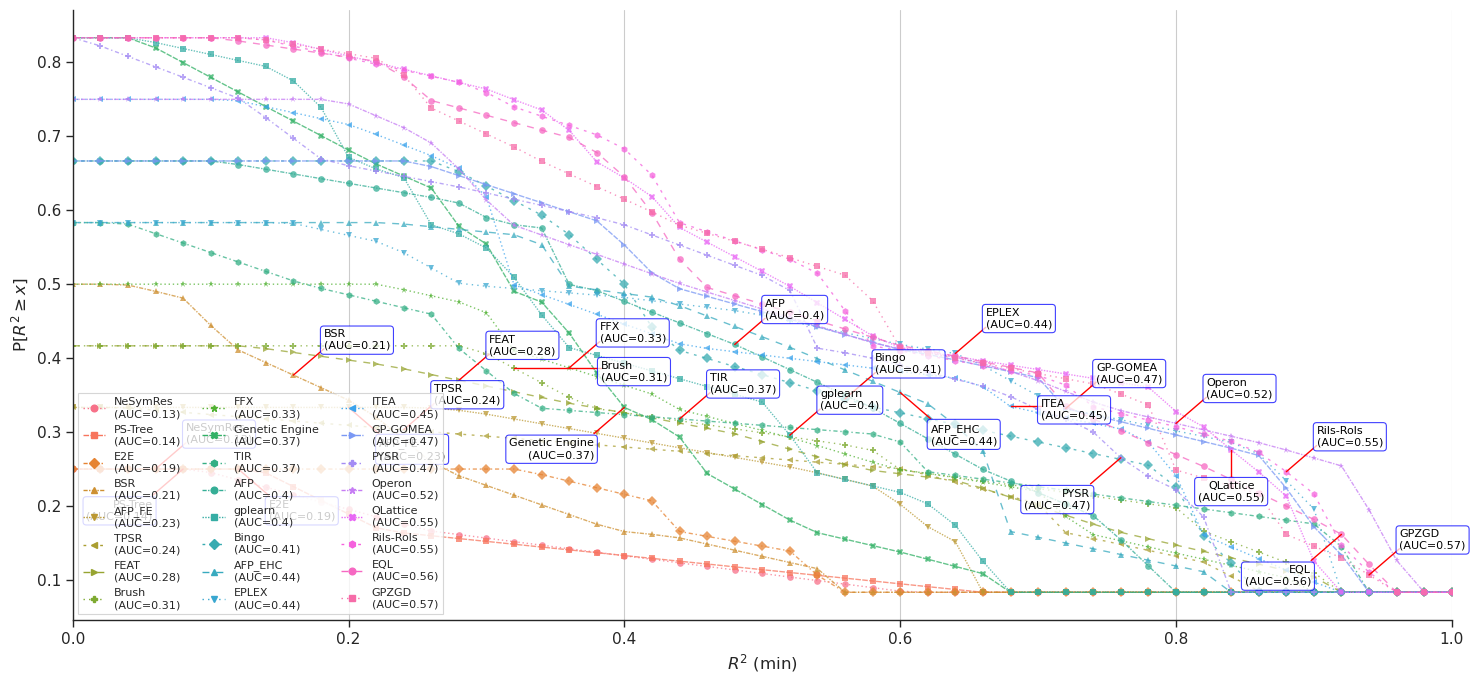

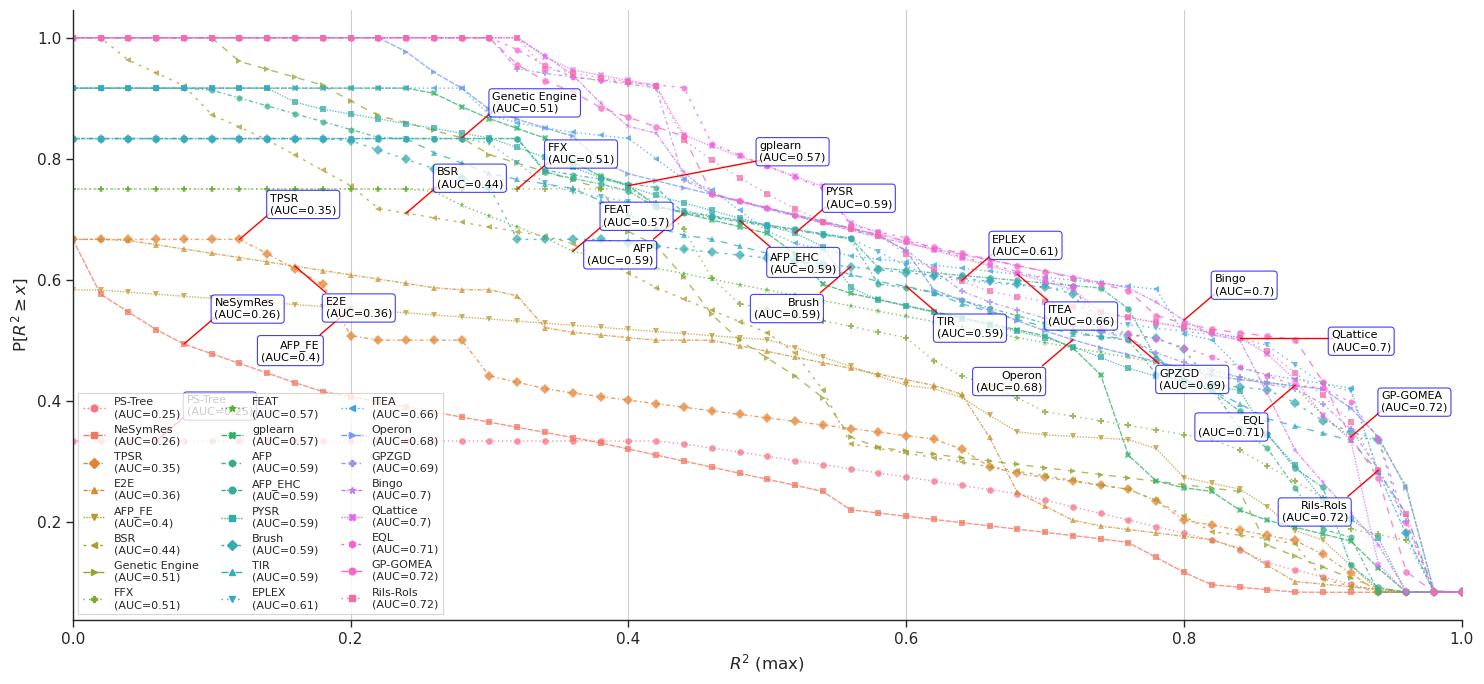

In [8]:
perfprof_plot(df_plot, "r2_test", errorbar=None, estimator=np.min)
save(name='r2_perf_full_min', figdir=figdir)

perfprof_plot(df_plot, "r2_test", errorbar=None, estimator=np.max)
save(name='r2_perf_full_max', figdir=figdir)

/tmp/ipykernel_590406/324054466.py:78: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_frames, x='perf_x', y='perf_y', linewidth=1, ls=":", ax=ax,
/tmp/ipykernel_590406/324054466.py:78: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_frames, x='perf_x', y='perf_y', linewidth=1, ls=":", ax=ax,
/tmp/ipykernel_590406/324054466.py:78: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_frames, x='perf_x', y='perf_y', linewidth=1, ls=":", ax=ax,
/tmp/ipykernel_590406/324054466.py:78: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_frames, x='perf_x', y='perf_y', linewidth=1, ls=":", ax=ax,
/tmp/ipykernel_590406/324054466.py:78: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.li

saving ../figs/black-box-tuning//r2_perf_intervals.pdf


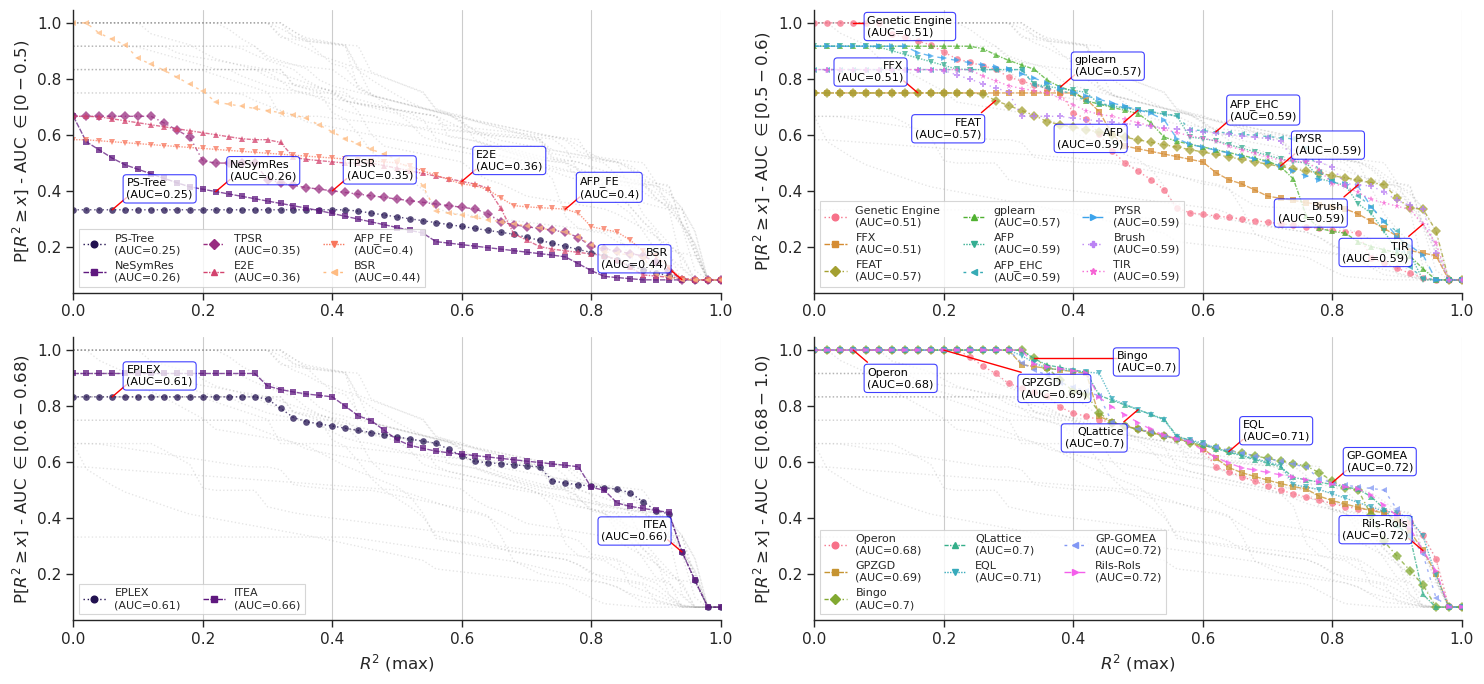

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(15, 7))

# Selecting based on overall performance
for i, (ax, interval) in enumerate(zip(fig.axes, [(0, 0.5), (0.5, 0.6), (0.6, 0.68), (0.68, 1.0)])):
    perfprof_plot(df_plot, "r2_test", interval, None, estimator=np.max, ax=ax, legend=True, xlabel=i>1)
    
save(name=f'r2_perf_intervals'.replace(", ", "-"), figdir=figdir)

/tmp/ipykernel_590406/1619611249.py:40: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  h.tight_layout()


saving ../figs/black-box-tuning//training_time.pdf


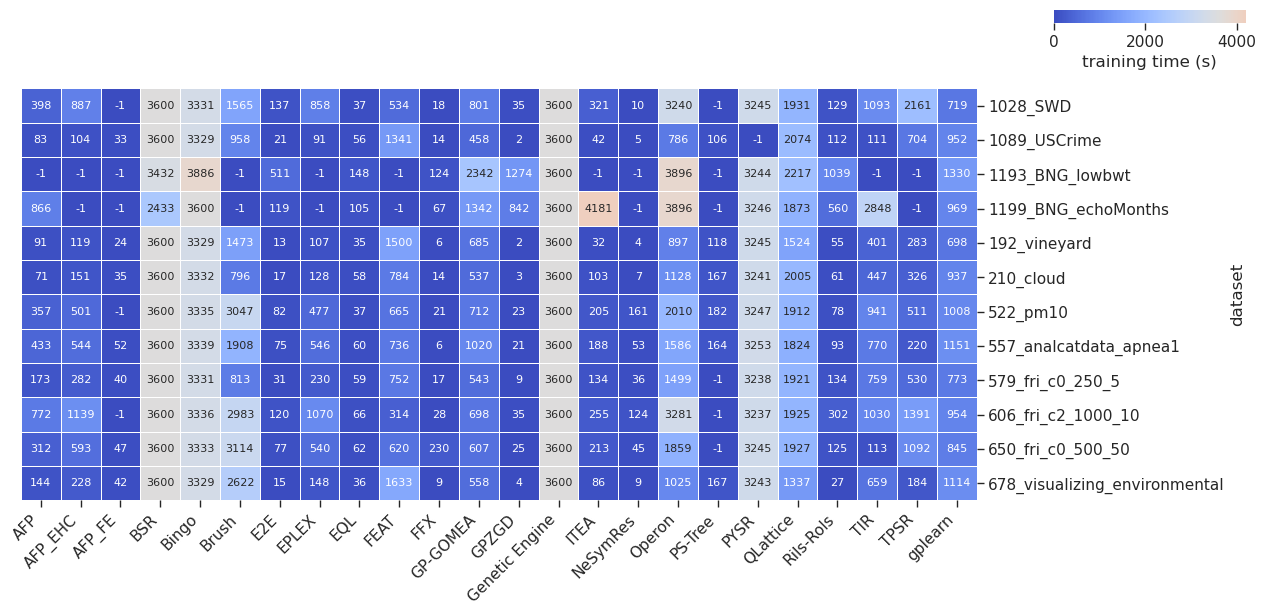

In [10]:
# Size of the best expressions
df_plot_heatmap = df_plot.copy().dropna(subset=['training time (s)'])

# Selecting as final result the best performing r2
idx = df_plot_heatmap.groupby(['algorithm', 'dataset'])['training time (s)'].transform(np.nanmax) == df_plot_heatmap['training time (s)']

# Eliminating duplicated r2 performances by picking the smaller model
df_plot_heatmap = df_plot_heatmap[idx].sort_values(['algorithm', 'dataset', 'training time (s)']).groupby(['algorithm', 'dataset']).head(1)[['algorithm', 'dataset', 'training time (s)']]

df_plot_heatmap = df_plot_heatmap.pivot(columns='algorithm', index='dataset', values='training time (s)').fillna(-1)

g = sns.clustermap(
    df_plot_heatmap,
    annot=True,
    fmt='.0f',
    cmap='coolwarm',
    annot_kws={'size': 8},
    linewidths=0.5,
    square=False,
    center=3600,
    row_cluster=False,
    col_cluster=False,
    cbar_pos=(.86, .92, .128, .019),
    # cbar_pos=(.82, .92, .148, .019),
    cbar_kws={'label': 'training time (s)', "orientation": "horizontal"},
    figsize=(15, 7)
)

# g.ax_heatmap.set_ylabel("")
g.ax_heatmap.set_xlabel("")
g.ax_row_dendrogram.set_visible(False) #suppress row dendrogram and changes figsize
g.ax_col_dendrogram.set_visible(False) #suppress column dendrogram and changes figsize

plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
save(name='training_time', figdir=figdir)

/home/ch246537/.conda/envs/srbench-brush-cpp/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ch246537/.conda/envs/srbench-brush-cpp/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


/tmp/ipykernel_590406/1619611249.py:40: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  h.tight_layout()


saving ../figs/black-box-tuning//r2_AUC_tuning.pdf


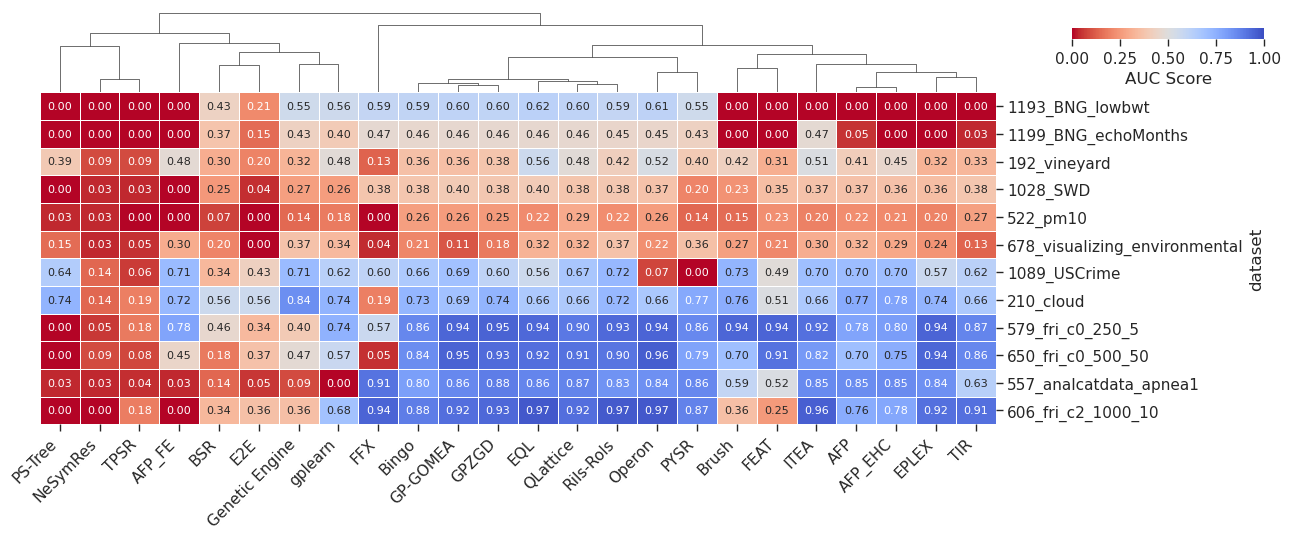

In [11]:
perf_table_df = perf_table(df_plot, "r2_test", errorbar=None).drop(columns=['mean_model_size'])
perf_table_pivot = perf_table_df.pivot(columns='algorithm', index='dataset', values='AUC').fillna(0.0)

# perf_table_pivot.style.background_gradient(axis=None, cmap='coolwarm_r')

g_cluster = sns.clustermap(
    perf_table_pivot,
    annot=True,
    fmt='.2f',
    cmap='coolwarm_r',
    center=0.5,
    vmin=0,
    vmax=1,
    annot_kws={'size': 8},
    linewidths=0.5,
    square=False,
    cbar_pos=(.86, .92, .128, .019),
    # cbar_pos=(.82, .92, .148, .019),
    cbar_kws={'label': 'AUC Score', "orientation": "horizontal"},
    figsize=(15, 6)
)

# g_cluster.ax_heatmap.set_ylabel("")
g_cluster.ax_heatmap.set_xlabel("")
g_cluster.ax_row_dendrogram.set_visible(False) #suppress row dendrogram and changes figsize
# g_cluster.ax_col_dendrogram.set_visible(False) #suppress column dendrogram and changes figsize

plt.setp(g_cluster.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
save(name='r2_AUC_tuning', figdir=figdir)

algorithm,AFP,AFP_EHC,AFP_FE,BSR,Bingo,Brush,E2E,EPLEX,EQL,FEAT,...,ITEA,NeSymRes,Operon,PS-Tree,PYSR,QLattice,Rils-Rols,TIR,TPSR,gplearn
dataset,,,,,,,,,,,,,,,,,,,,,
1028_SWD,16.0,28.0,NaN,25.0,34.0,47.0,78.0,57.0,61.0,30.0,...,35.0,11.0,25.0,NaN,2.0,25.0,22.0,69.0,56.0,34.0
1089_USCrime,7.0,10.0,15.0,56.0,26.0,12.0,61.0,9.0,487.0,7.0,...,12.0,13.0,13.0,306.0,NaN,27.0,3.0,22.0,49.0,6.0
1193_BNG_lowbwt,NaN,NaN,NaN,11.0,36.0,NaN,46.0,NaN,195.0,NaN,...,NaN,NaN,71.0,NaN,3.0,32.0,31.0,NaN,NaN,14.0
1199_BNG_echoMonths,37.0,NaN,NaN,12.0,28.0,NaN,87.0,NaN,167.0,NaN,...,130.0,NaN,71.0,NaN,3.0,36.0,16.0,28.0,NaN,10.0
192_vineyard,9.0,8.0,9.0,19.0,31.0,32.0,41.0,49.0,20.0,65.0,...,9.0,18.0,18.0,1594.0,15.0,10.0,3.0,36.0,37.0,62.0
210_cloud,7.0,10.0,31.0,31.0,28.0,7.0,39.0,59.0,1489.0,19.0,...,7.0,11.0,14.0,8169.0,13.0,23.0,14.0,12.0,35.0,11.0
522_pm10,16.0,31.0,NaN,8.0,28.0,47.0,1.0,40.0,47.0,21.0,...,130.0,19.0,37.0,3653.0,3.0,37.0,21.0,94.0,1.0,18.0
557_analcatdata_apnea1,24.0,21.0,64.0,45.0,49.0,36.0,58.0,62.0,127.0,17.0,...,132.0,11.0,48.0,2452.0,14.0,49.0,17.0,23.0,14.0,1.0
579_fri_c0_250_5,28.0,14.0,31.0,28.0,32.0,52.0,22.0,59.0,140.0,52.0,...,91.0,17.0,36.0,NaN,25.0,50.0,38.0,68.0,35.0,47.0


/tmp/ipykernel_590406/1619611249.py:40: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  h.tight_layout()


saving ../figs/black-box-tuning//model_sizes.pdf


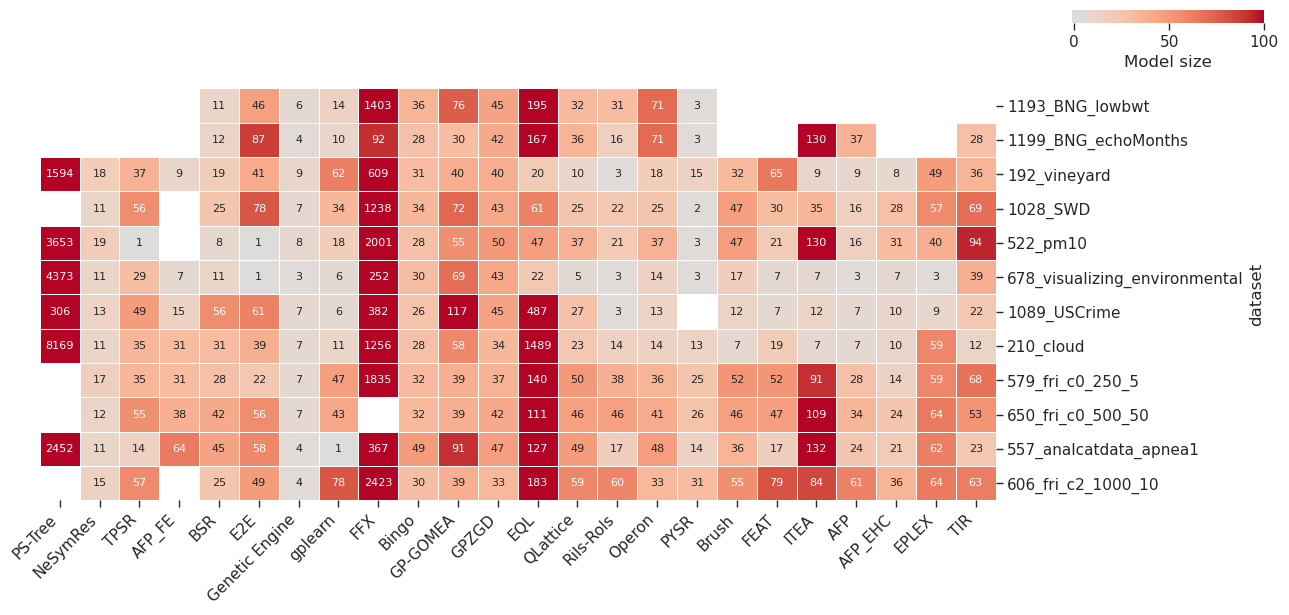

In [12]:
# empty cells --> there is no results

# Size of the best expressions
df_plot_heatmap = df_plot.copy().dropna(subset=['r2_zero_test', 'model_size'])

# ignoring bad results. If the line below is commented out, then:
# -1 cells    --> something happened during model size evaluation
df_plot_heatmap = df_plot_heatmap[df_plot_heatmap['model_size']>0]

# df_plot_heatmap[df_plot_heatmap['model_size']<=0]['model_size'] = -1

# Selecting as final result the best performing r2
idx = df_plot_heatmap.groupby(['algorithm', 'dataset'])['r2_zero_test'].transform(np.nanmax) == df_plot_heatmap['r2_zero_test']

# Eliminating duplicated r2 performances by picking the smaller model
df_plot_heatmap = df_plot_heatmap[idx].sort_values(['algorithm', 'dataset', 'model_size']).groupby(['algorithm', 'dataset']).head(1)[['algorithm', 'dataset', 'model_size']]

df_plot_heatmap = df_plot_heatmap.pivot(columns='algorithm', index='dataset', values='model_size') # .fillna(-1)

display(df_plot_heatmap)

# reordering so we can have matching row order
df_plot_heatmap = df_plot_heatmap.iloc[g_cluster.dendrogram_row.reordered_ind]
df_plot_heatmap = df_plot_heatmap.iloc[:, g_cluster.dendrogram_col.reordered_ind]

g = sns.clustermap(
    df_plot_heatmap,
    annot=True,
    fmt='.0f',
    cmap='coolwarm',
    vmin=-1,
    center=0,
    vmax=100,
    annot_kws={'size': 8},
    linewidths=0.5,
    square=False,
    row_cluster=False,
    col_cluster=False,
    cbar_pos=(.86, .92, .128, .019),
    # cbar_pos=(.82, .92, .148, .019),
    cbar_kws={'label': 'Model size', "orientation": "horizontal"},
    figsize=(15, 7)
)

# g.ax_heatmap.set_ylabel("")
g.ax_heatmap.set_xlabel("")
g.ax_row_dendrogram.set_visible(False) #suppress row dendrogram and changes figsize
g.ax_col_dendrogram.set_visible(False) #suppress column dendrogram and changes figsize

plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
save(name='model_sizes', figdir=figdir)

/home/ch246537/.conda/envs/srbench-brush-cpp/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ch246537/.conda/envs/srbench-brush-cpp/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Number of valid runs:
[ 0.  0.  0.  0. 24. 15. 30. 30. 29. 30. 30. 30. 30. 30. 30. 30. 30.  0.
  0.  0.  0.  0.  0.  0.]
[ 0.  0.  0.  0. 29. 18. 30. 30. 30. 30. 30. 30. 29. 30. 30. 29. 30.  0.
  0. 30.  2.  0.  0.  1.]
[26.  6.  5.  8. 20. 12. 22. 26.  7. 23. 22. 24. 27. 25. 26. 29. 22. 25.
 17. 26. 14. 15. 21. 21.]
[ 0.  1.  2.  0. 30.  4. 30. 30. 30. 30. 30. 30. 30. 30. 30. 30. 30. 17.
 28. 30. 21. 11. 30. 30.]
[ 1.  1.  0.  0. 16.  0. 27. 30.  0. 30. 30. 30. 30. 30. 30. 30. 30. 16.
 29. 30.  8. 14. 29. 30.]
[18.  1.  2. 22. 22.  0. 29. 29.  2. 21.  9. 18. 28. 27. 29. 21. 29. 25.
 21. 25. 10. 17. 21. 15.]
[30.  6.  4. 13. 18. 21. 30. 29. 29. 28. 29. 29. 30. 29. 30.  3.  0. 30.
 20. 28. 13. 18. 28. 26.]
[29.  5.  7. 20. 24. 23. 30. 30. 10. 28. 27. 29. 29. 27. 28. 26. 29. 30.
 22. 26. 18. 22. 28. 27.]
[ 0.  5.  7. 21. 26. 22. 30. 30. 28. 30. 30. 30. 30. 30. 30. 30. 30. 30.
 30. 30.  5.  2. 30. 30.]
[ 0.  6.  6. 15. 16. 20. 30. 30.  0. 30. 30. 30. 30. 30. 30. 30. 30. 22.
 29. 30. 12. 1

/tmp/ipykernel_590406/1619611249.py:40: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  h.tight_layout()


saving ../figs/black-box-tuning//r2_AUC_tuning_with_sizes.pdf


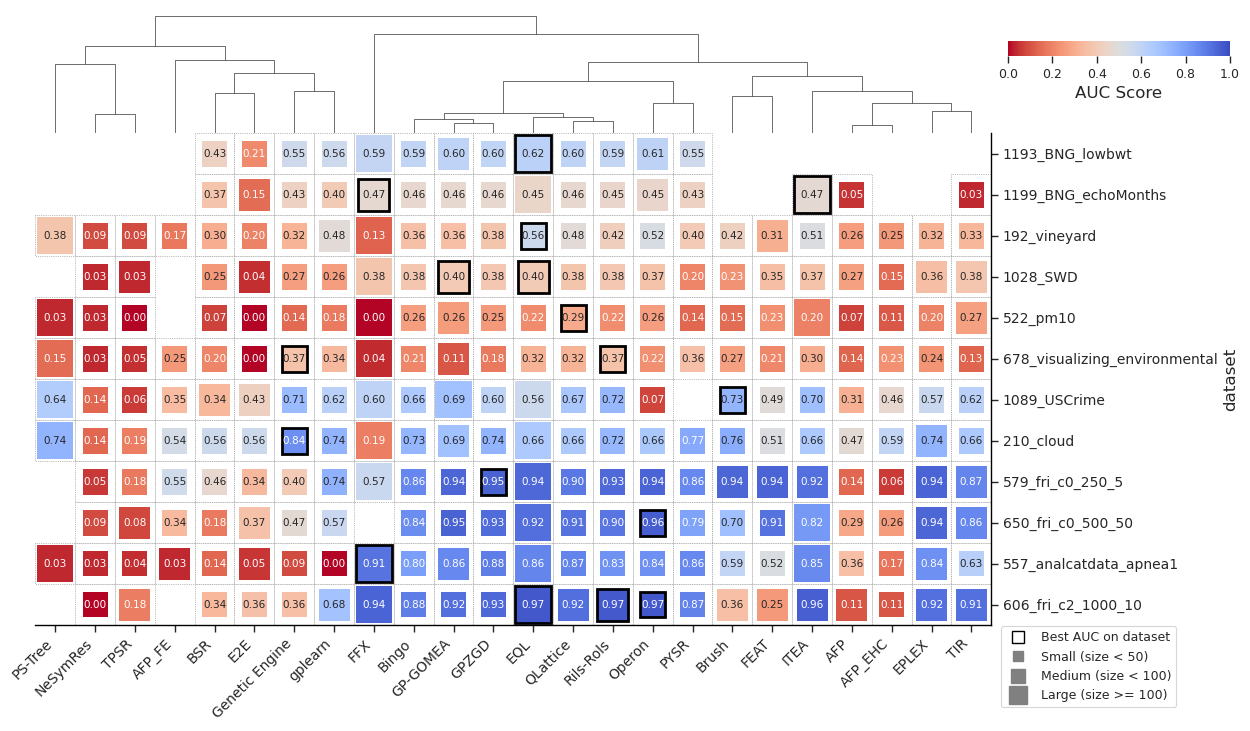

In [13]:
# no text --> there is no AUC score to show
# no box  --> size of best expression is invalid 
# Notice that AUC will be higher for methods with more runs.

# combining both AUC and size
df_plot_aux = df_plot.copy()
df_plot_aux = df_plot_aux[df_plot_aux['model_size']>0]

perf_table_df = perf_table(df_plot_aux, "r2_test", errorbar=None)

counts_table_pivot = perf_table_df.pivot(columns='algorithm', index='dataset', values='valid').fillna(0.0)
counts_table_pivot = counts_table_pivot.iloc[g_cluster.dendrogram_row.reordered_ind]
print("Number of valid runs:")
for i in range(counts_table_pivot.shape[0]):
    values = counts_table_pivot.iloc[i, g_cluster.dendrogram_col.reordered_ind].round(2).values
    print(values)


perf_table_pivot = perf_table_df.pivot(columns='algorithm', index='dataset', values='AUC') #.fillna(0.0)
# copying clusters from data with non-empty values (clustermap does not work with nans)
perf_table_pivot = perf_table_pivot.iloc[g_cluster.dendrogram_row.reordered_ind]
# perf_table_pivot = perf_table_pivot.iloc[:, g_cluster.dendrogram_col.reordered_ind]

g_cluster2 = sns.clustermap(
    perf_table_pivot,
    annot=True,
    fmt='.2f',
    cmap='coolwarm_r', # crest, miko
    center=0.5,
    vmin=0,
    vmax=1,
    annot_kws={'size': 7.5},
    linewidths=0.5,
    square=False,
    row_cluster=False,
    col_cluster=True,
    col_linkage=g_cluster.dendrogram_col.linkage,
    # cbar_pos=(.84, .18, .12, .019),
    cbar_pos=(.82, .92, .148, .019),
    cbar_kws={'label': 'AUC Score', "orientation": "horizontal"},
    figsize=(15, 8)
)

g_cluster2.ax_cbar.tick_params(labelsize=9)

# finding the best
best_idxs = []
print(perf_table_pivot.shape)
flat_index = 0
for i in range(perf_table_pivot.shape[0]):
    values = perf_table_pivot.iloc[i, g_cluster.dendrogram_col.reordered_ind].round(2).values
    not_nan_values = values[~np.isnan(values)]
    print(values)
    if len(not_nan_values) == 0:
        continue

    best_idxs += [flat_index+j for j in range(len(not_nan_values))
                                          if not_nan_values[j] == np.max(not_nan_values)]
    flat_index += len(not_nan_values)

# g_cluster2.ax_heatmap.set_ylabel("")
g_cluster2.ax_heatmap.set_xlabel("")
g_cluster2.ax_row_dendrogram.set_visible(False) #suppress row dendrogram and changes figsize
# g_cluster2.ax_col_dendrogram.set_visible(False) #suppress column dendrogram and changes figsize

plt.setp(g_cluster2.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=10)
plt.setp(g_cluster2.ax_heatmap.get_yticklabels(), fontsize=10)

# Making size proportional to best model size
for i in range(len(g_cluster2.ax_heatmap.get_children())):
    if not isinstance(g_cluster2.ax_heatmap.get_children()[i], matplotlib.text.Text):
        continue

    # Getting the text for both clustermaps. they should have the same shapes
    t_auc = g_cluster2.ax_heatmap.get_children()[i]
    t_size = g.ax_heatmap.get_children()[i]

    # Facecolor from the flattened version. children[0] is the colormesh.
    x, y = t_size.get_position()
    
    c = g_cluster2.ax_heatmap.get_children()[0].get_facecolors()[
        int(x-0.5 + (y-0.5)*perf_table_pivot.shape[1])
    ]

    # print(t_auc.get_position())
    # print(t_auc.get_text())
    # print(t_size.get_position())
    # print(t_size.get_text())

    if t_auc.get_text()=='' or t_size.get_text()=='':
        #t_auc.set_text("")
        g_cluster2.ax_heatmap.add_patch( Rectangle([p-0.5 for p in t_size.get_position()], 1, 1, fc ='white', ec ='gray', lw=0.5, ls=':') ) # border
        continue

    # Reduction rate
    rate = 1 - min(max(int(t_size.get_text())/200, 0), 1)

    # Discrete version of rate
    model_size = int(t_size.get_text())
    rate = -0.05 if model_size >= 100 else (0.4 if model_size > 50 else 0.9)

    totsize = 0.9 - rate*0.3
    # g_cluster2.ax_heatmap.add_patch( Rectangle([p-0.475 for p in t.get_position()], 1, 1, fc ='white', ec ='white', lw=1) ) # white background
    g_cluster2.ax_heatmap.add_patch( Rectangle([p-0.5 for p in t_size.get_position()], 1, 1, fc ='white', ec ='gray', lw=0.5, ls=':') ) # border
    if i-1 in best_idxs:
        g_cluster2.ax_heatmap.add_patch( Rectangle([p-(totsize/2) for p in t_size.get_position()], totsize, totsize, fc=c, ec ='black', lw=2) ) # proportional box
    else:
        g_cluster2.ax_heatmap.add_patch( Rectangle([p-(totsize/2) for p in t_size.get_position()], totsize, totsize, fc=c, ec ='none', lw=0) ) # proportional box

for i, spine in g_cluster2.ax_heatmap.spines.items():
    if i=='left' or i=='top':
        continue
    spine.set_visible(True)
    spine.set_edgecolor('black')

# Creating legend for size
patch_best = g_cluster2.ax_heatmap.plot([],[], marker='s', ms=8, lw=2, markeredgecolor='k', color='white', label='Best AUC on dataset')
patch_small = g_cluster2.ax_heatmap.plot([],[], marker='s', ms=7, ls="", color='gray', label='Small (size < 50)')
patch_medium = g_cluster2.ax_heatmap.plot([],[], marker='s', ms=10, ls="", color='gray', label='Medium (size < 100)')
patch_large = g_cluster2.ax_heatmap.plot([],[], marker='s', ms=13, ls="", color='gray', label='Large (size >= 100)')

g_cluster2.ax_heatmap.legend(handles=patch_best+patch_small+patch_medium+patch_large, bbox_to_anchor=(1.2, 0.01), fontsize=9)

save(name='r2_AUC_tuning_with_sizes', figdir=figdir)